✅ Full symmetric shape created successfully!
   Total area: 1459805.75 mm²
   Bounds: (-1525.6, -338.1, 1525.6, 338.1)
   Square hole added (118.0×118.0 mm) at center
   Final area with hole: 1459805.75 mm²


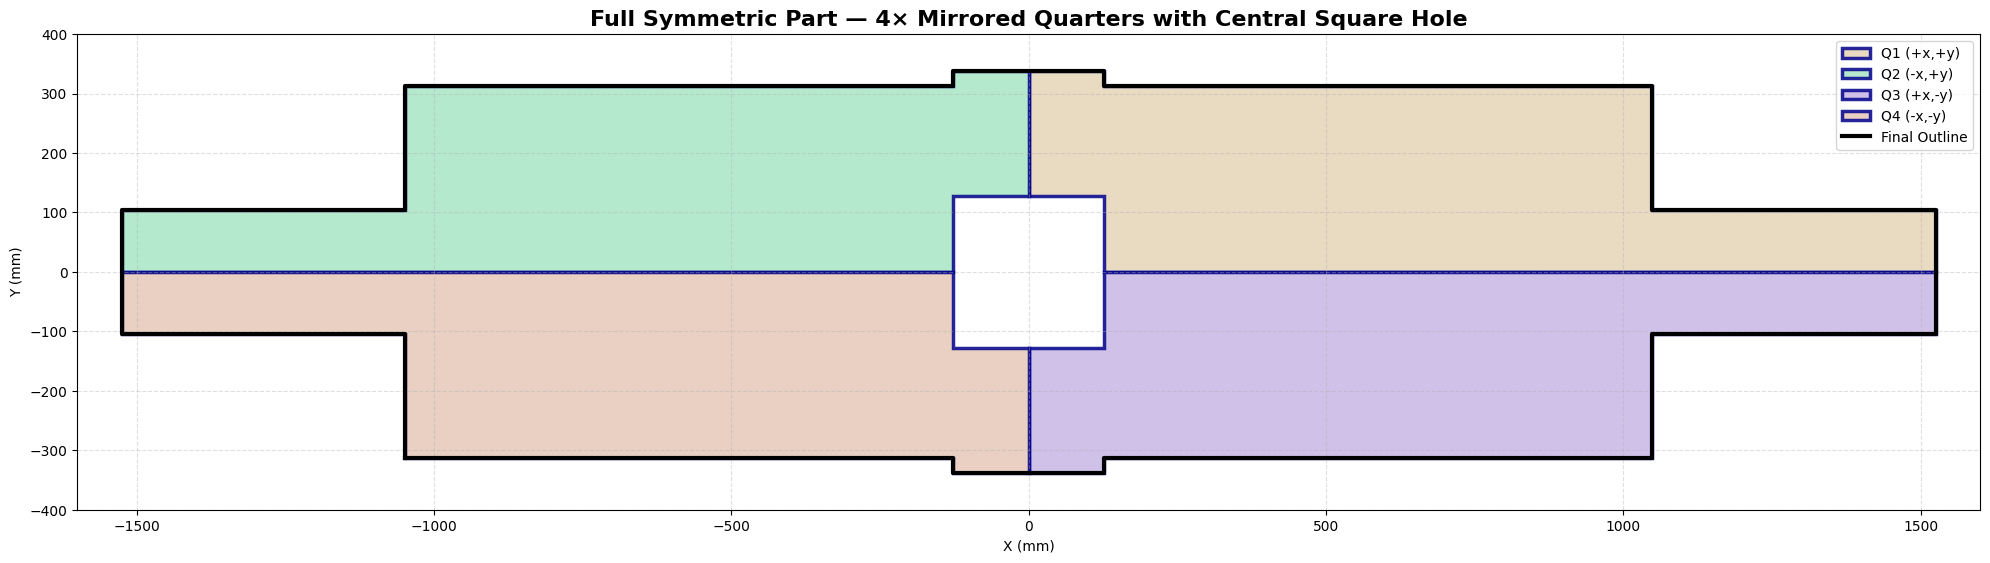


Final exterior coordinates (first 20 points):
   0: (-1049.20,  -312.90)
   1: (-1049.20,  -104.30)
   2: (-1525.60,  -104.30)
   3: (-1525.60,    -0.00)
   4: (-1525.60,   104.30)
   5: (-1049.20,   104.30)
   6: (-1049.20,   312.90)
   7: ( -127.45,   312.90)
   8: ( -127.45,   338.10)
   9: (   -0.00,   338.10)
  10: (  127.45,   338.10)
  11: (  127.45,   312.90)
  12: ( 1049.20,   312.90)
  13: ( 1049.20,   104.30)
  14: ( 1525.60,   104.30)
  15: ( 1525.60,     0.00)
  16: ( 1525.60,  -104.30)
  17: ( 1049.20,  -104.30)
  18: ( 1049.20,  -312.90)
  19: (  127.45,  -312.90)


In [5]:
import numpy as np
from shapely.geometry import Polygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

# ====================== ORIGINAL QUARTER (Q1: +x, +y) ======================
outer_vertices_q1 = np.array([
    (115.60 + 11.85, 0.00),
    (1525.60, 0.00),
    (1525.60, 312.9 / 3.),
    (1049.20, 312.9 / 3.),
    (1049.20, 312.9),
    (115.60 + 11.85, 312.9),
    (115.60 + 11.85, 338.10),
    (0.00, 338.10),
    (0.00, 115.60 + 11.85),
    (115.60 + 11.85, 115.60 + 11.85),
])

# ====================== CREATE 4 QUARTERS ======================
def mirror_vertices(vertices, mx=1, my=1):
    verts = vertices.copy()
    verts[:, 0] *= mx
    verts[:, 1] *= my
    return verts

poly_q1 = Polygon(outer_vertices_q1)                                      # Q1: +x +y
poly_q2 = Polygon(mirror_vertices(outer_vertices_q1, mx=-1, my=1))       # Q2: -x +y
poly_q3 = Polygon(mirror_vertices(outer_vertices_q1, mx=1, my=-1))       # Q3: +x -y
poly_q4 = Polygon(mirror_vertices(outer_vertices_q1, mx=-1, my=-1))      # Q4: -x -y

# ====================== MERGE INTO FULL SHAPE ======================
full_shape = unary_union([poly_q1, poly_q2, poly_q3, poly_q4])

print("✅ Full symmetric shape created successfully!")
print(f"   Total area: {full_shape.area:.2f} mm²")
print(f"   Bounds: {full_shape.bounds}")

# Optional: Add centered square hole (118 mm side)
add_square_hole = True  # Change to False if you don't want the hole

if add_square_hole:
    side = 118.0
    half = side / 2
    square = Polygon([
        (-half, -half), (half, -half),
        (half, half), (-half, half)
    ])
    final_shape = full_shape.difference(square)
    print(f"   Square hole added ({side}×{side} mm) at center")
    print(f"   Final area with hole: {final_shape.area:.2f} mm²")
else:
    final_shape = full_shape

# ====================== PLOT ======================
fig, ax = plt.subplots(figsize=(20, 12))
ax.set_aspect('equal')

colors = ['#E6D5B8', '#A8E6C5', '#C8B6E6', '#E6C8B8']
labels = ['Q1 (+x,+y)', 'Q2 (-x,+y)', 'Q3 (+x,-y)', 'Q4 (-x,-y)']
polys = [poly_q1, poly_q2, poly_q3, poly_q4]

for poly, color, label in zip(polys, colors, labels):
    coords = np.array(poly.exterior.coords)
    mpl_poly = MplPolygon(coords, closed=True, facecolor=color, 
                         edgecolor='darkblue', linewidth=2.5, alpha=0.85, label=label)
    ax.add_patch(mpl_poly)

# Plot final outline
if final_shape.geom_type == 'Polygon':
    outline = np.array(final_shape.exterior.coords)
    ax.plot(outline[:,0], outline[:,1], 'k-', linewidth=3, label='Final Outline')
else:
    for geom in final_shape.geoms:
        outline = np.array(geom.exterior.coords)
        ax.plot(outline[:,0], outline[:,1], 'k-', linewidth=3)

ax.set_title('Full Symmetric Part — 4× Mirrored Quarters' + 
             (' with Central Square Hole' if add_square_hole else ''),
             fontsize=16, fontweight='bold')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
ax.set_xlim(-1600, 1600)
ax.set_ylim(-400, 400)
plt.tight_layout()
plt.show()

# ====================== EXPORT VERTICES (optional) ======================
print("\nFinal exterior coordinates (first 20 points):")
if final_shape.geom_type == 'Polygon':
    coords = list(final_shape.exterior.coords)
else:
    coords = list(final_shape.geoms[0].exterior.coords)  # take first if MultiPolygon
for i, (x, y) in enumerate(coords[:20]):
    print(f"  {i:2d}: ({x:8.2f}, {y:8.2f})")

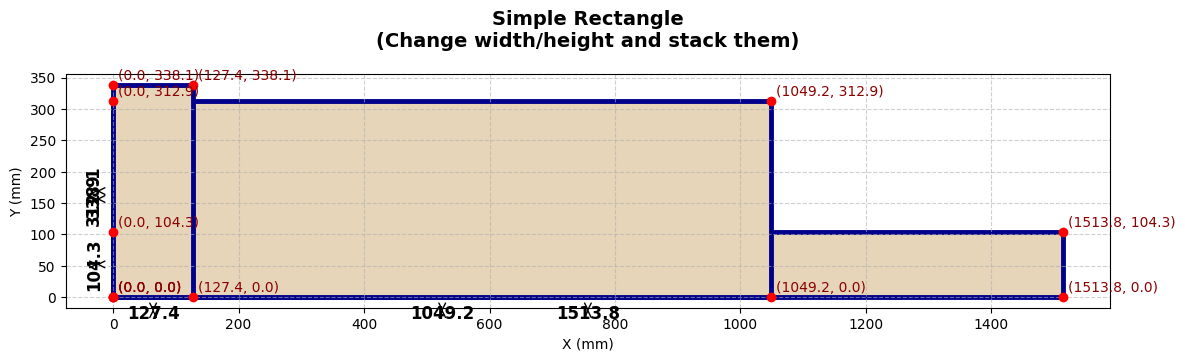

Rectangle corners:
(0, 0)
(127.44999999999999, 0)
(127.44999999999999, 338.1)
(0, 338.1)


NameError: name 'square_side' is not defined